In [11]:
# Cell 2 — Imports
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

from statsmodels.tsa.holtwinters import ExponentialSmoothing

pd.set_option("display.max_columns", 50)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

print("All libraries loaded successfully.")


All libraries loaded successfully.


In [12]:
# Cell 3 — Load sub.xlsx
FILE = "sub.xlsx"

df = pd.read_excel(FILE, sheet_name=0)
df["invoice_date"] = pd.to_datetime(df["invoice_date"], errors="coerce")

print("Dataset loaded successfully.")
print("Rows:", f"{len(df):,}")
print("Columns:", len(df.columns))

display(df.head())


Dataset loaded successfully.
Rows: 85,448
Columns: 12


,invoice_id,invoice_date,invoice_status,account_id,region,segment,subscription_id,plan_name,seats,mrr,amount_due,amount_paid
0,INV0000001,2024-06-11,paid,A000001,LATAM,SMB,S000001,Growth,13,199.00,199.00,199.00
1,INV0000002,2024-07-11,paid,A000001,LATAM,SMB,S000001,Growth,13,199.00,199.00,199.00
2,INV0000003,2024-08-11,paid,A000001,LATAM,SMB,S000001,Growth,13,199.00,199.00,199.00
3,INV0000004,2024-09-11,paid,A000001,LATAM,SMB,S000001,Growth,13,199.00,199.00,199.00
4,INV0000005,2024-10-11,paid,A000001,LATAM,SMB,S000001,Growth,13,199.00,199.00,199.00


In [13]:
# Cell 4 — Basic data inspection
print("Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

print("\nData types:")
display(df.dtypes.to_frame("dtype"))

print("\nDate range:")
print(df["invoice_date"].min(), "to", df["invoice_date"].max())

print("\nUnique accounts:", df["account_id"].nunique())
print("Unique subscriptions:", df["subscription_id"].nunique())
print("Unique invoices:", df["invoice_id"].nunique())


Shape: (85448, 12)

Columns:
['invoice_id', 'invoice_date', 'invoice_status', 'account_id', 'region', 'segment', 'subscription_id', 'plan_name', 'seats', 'mrr', 'amount_due', 'amount_paid']

Data types:


,dtype
invoice_id,str
invoice_date,datetime64[us]
invoice_status,str
account_id,str
region,str
segment,str
subscription_id,str
plan_name,str
seats,int64
mrr,float64



Date range:
2023-01-04 00:00:00 to 2025-12-28 00:00:00

Unique accounts: 5000
Unique subscriptions: 5000
Unique invoices: 85448


In [14]:
# Cell 5 — Missing values and duplicates
missing = df.isna().sum().sort_values(ascending=False)

print("Missing values:")
display(missing.to_frame("missing_count"))

print("Missing percentage:")
display((missing / len(df) * 100).round(2).to_frame("missing_percent"))

print("Duplicate invoice IDs:", df["invoice_id"].duplicated().sum())
print("Duplicate complete rows:", df.duplicated().sum())


Missing values:


,missing_count
region,21618
invoice_id,0
invoice_status,0
invoice_date,0
account_id,0
segment,0
subscription_id,0
plan_name,0
seats,0
mrr,0


Missing percentage:


,missing_percent
region,25.30
invoice_id,0.00
invoice_status,0.00
invoice_date,0.00
account_id,0.00
segment,0.00
subscription_id,0.00
plan_name,0.00
seats,0.00
mrr,0.00


Duplicate invoice IDs: 0
Duplicate complete rows: 0


In [15]:
# Cell 6 — Category checks
print("Invoice status:")
display(df["invoice_status"].value_counts(dropna=False))

print("Segment:")
display(df["segment"].value_counts(dropna=False))

print("Plan:")
display(df["plan_name"].value_counts(dropna=False))


Invoice status:


invoice_status
paid    80101
open     5311
void       36
Name: count, dtype: int64

Segment:


segment
SMB           60277
mid_market    19998
enterprise     5173
Name: count, dtype: int64

Plan:


plan_name
Starter       41551
Growth        27497
Scale         11605
Enterprise     4795
Name: count, dtype: int64

In [16]:
# Cell 7 — Clean the dataset
financial_cols = ["mrr", "amount_due", "amount_paid"]

df["region"] = df["region"].fillna("Unknown")

for col in financial_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")

print("Missing financial values after cleaning:")
display(df[financial_cols].isna().sum().to_frame("missing_count"))

print("Missing region after cleaning:", df["region"].isna().sum())


Missing financial values after cleaning:


,missing_count
mrr,0
amount_due,0
amount_paid,0


Missing region after cleaning: 0


In [17]:
# Cell 8 — Enterprise dataset
ent = df[df["segment"].str.lower().eq("enterprise")].copy()

print("Enterprise invoice records:", f"{len(ent):,}")
print("Unique enterprise accounts:", ent["account_id"].nunique())
print("Enterprise date range:", ent["invoice_date"].min().date(), "to", ent["invoice_date"].max().date())

display(ent.head())


Enterprise invoice records: 5,173
Unique enterprise accounts: 305
Enterprise date range: 2023-01-18 to 2025-12-28


,invoice_id,invoice_date,invoice_status,account_id,region,segment,subscription_id,plan_name,seats,mrr,amount_due,amount_paid
170,INV0000171,2024-10-10,paid,A000013,APAC,enterprise,S000013,Scale,47,799.00,799.00,799.00
171,INV0000172,2024-11-10,paid,A000013,APAC,enterprise,S000013,Scale,47,799.00,799.00,799.00
172,INV0000173,2024-12-10,paid,A000013,APAC,enterprise,S000013,Scale,47,799.00,799.00,799.00
173,INV0000174,2025-01-10,paid,A000013,APAC,enterprise,S000013,Scale,47,799.00,799.00,799.00
174,INV0000175,2025-02-10,paid,A000013,APAC,enterprise,S000013,Scale,47,799.00,799.00,799.00


In [18]:
# Cell 9 — Current churn calculation
latest_date = ent["invoice_date"].max()

last_invoice = ent.groupby("account_id")["invoice_date"].max()
days_since_last = (latest_date - last_invoice).dt.days

current_account_status = pd.DataFrame({
    "account_id": last_invoice.index,
    "last_invoice": last_invoice.values,
    "days_since_last_invoice": days_since_last.values
})

current_account_status["churned_90d"] = (
    current_account_status["days_since_last_invoice"] >= 90
).astype(int)

current_churn_rate = current_account_status["churned_90d"].mean()

print("Latest date:", latest_date.date())
print("Enterprise accounts:", len(current_account_status))
print("Currently churned:", current_account_status["churned_90d"].sum())
print(f"Current churn rate: {current_churn_rate:.2%}")

display(
    current_account_status["churned_90d"]
    .value_counts()
    .rename({0: "Active", 1: "Churned"})
    .to_frame("client_count")
)


Latest date: 2025-12-28
Enterprise accounts: 305
Currently churned: 55
Current churn rate: 18.03%


,client_count
churned_90d,
Active,250
Churned,55


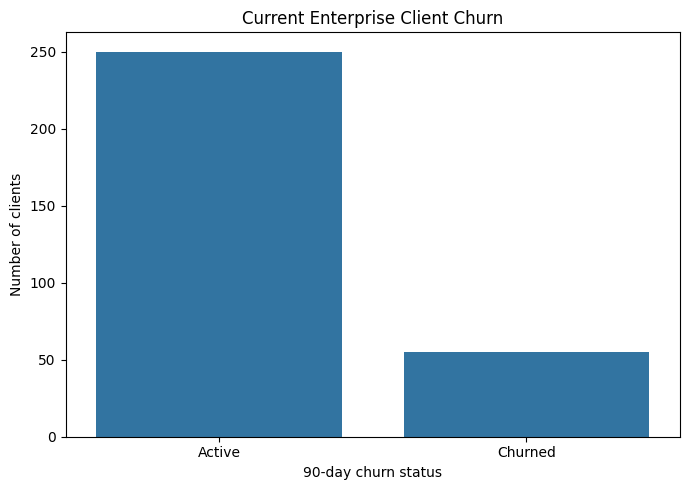

In [19]:
# Cell 10 — Current churn visualization
plt.figure(figsize=(7, 5))
sns.countplot(
    data=current_account_status,
    x="churned_90d",
    order=[0, 1]
)
plt.title("Current Enterprise Client Churn")
plt.xlabel("90-day churn status")
plt.ylabel("Number of clients")
plt.xticks([0, 1], ["Active", "Churned"])
plt.tight_layout()
plt.show()


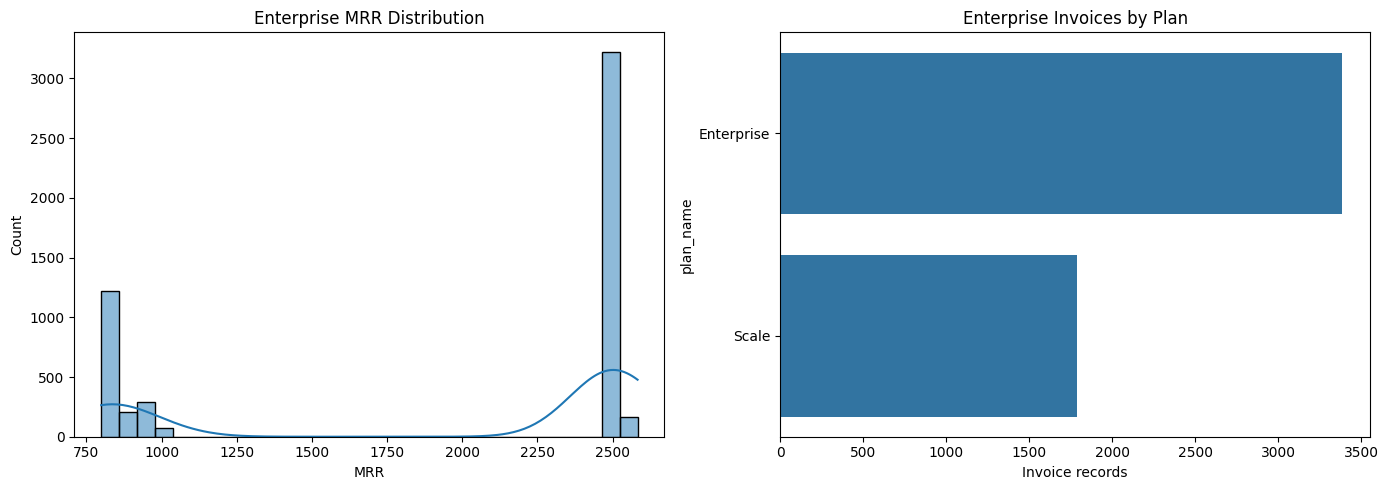

Enterprise plan distribution:


,invoice_count
plan_name,
Enterprise,3386
Scale,1787


In [20]:
# Cell 11 — Enterprise EDA
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(ent["mrr"], bins=30, kde=True, ax=axes[0])
axes[0].set_title("Enterprise MRR Distribution")
axes[0].set_xlabel("MRR")

sns.countplot(
    data=ent,
    y="plan_name",
    order=ent["plan_name"].value_counts().index,
    ax=axes[1]
)
axes[1].set_title("Enterprise Invoices by Plan")
axes[1].set_xlabel("Invoice records")

plt.tight_layout()
plt.show()

print("Enterprise plan distribution:")
display(ent["plan_name"].value_counts().to_frame("invoice_count"))


In [21]:
# Cell 12 — Function to create historical prediction snapshots
def build_snapshot_dataset(data, start_date="2024-01-31", end_date="2025-09-30"):
    records = []

    for snap in pd.date_range(start_date, end_date, freq="ME"):
        past = data[data["invoice_date"] <= snap].copy()

        # Last activity for every account
        last_invoice = past.groupby("account_id")["invoice_date"].max()

        # Only currently active accounts enter the prediction population
        eligible = last_invoice[
            (snap - last_invoice).dt.days <= 90
        ].index

        if len(eligible) == 0:
            continue

        # ---------------------------
        # Previous 90 days
        # ---------------------------
        w90 = past[
            past["invoice_date"] > snap - pd.Timedelta(days=90)
        ]
        g90 = w90.groupby("account_id")

        feat = pd.DataFrame(index=eligible)

        feat["invoice_count_90d"] = (
            g90.size().reindex(eligible).fillna(0)
        )

        feat["revenue_90d"] = (
            g90["amount_paid"].sum().reindex(eligible).fillna(0)
        )

        feat["amount_due_90d"] = (
            g90["amount_due"].sum().reindex(eligible).fillna(0)
        )

        feat["amount_paid_90d"] = (
            g90["amount_paid"].sum().reindex(eligible).fillna(0)
        )

        feat["payment_rate_90d"] = np.divide(
            feat["amount_paid_90d"],
            feat["amount_due_90d"],
            out=np.zeros(len(feat), dtype=float),
            where=feat["amount_due_90d"].to_numpy() != 0
        )

        feat["open_invoices_90d"] = (
            g90["invoice_status"]
            .apply(lambda s: (s == "open").sum())
            .reindex(eligible)
            .fillna(0)
        )

        feat["avg_mrr_90d"] = (
            g90["mrr"].mean().reindex(eligible).fillna(0)
        )

        feat["avg_seats_90d"] = (
            g90["seats"].mean().reindex(eligible).fillna(0)
        )

        feat["days_since_last"] = (
            snap - last_invoice.reindex(eligible)
        ).dt.days

        # ---------------------------
        # Previous 30 days
        # ---------------------------
        w30 = past[
            past["invoice_date"] > snap - pd.Timedelta(days=30)
        ]
        g30 = w30.groupby("account_id")

        feat["invoice_count_30d"] = (
            g30.size().reindex(eligible).fillna(0)
        )

        feat["revenue_30d"] = (
            g30["amount_paid"].sum().reindex(eligible).fillna(0)
        )

        # ---------------------------
        # Latest known account attributes
        # ---------------------------
        latest_rows = (
            past[past["account_id"].isin(eligible)]
            .sort_values("invoice_date")
            .groupby("account_id")
            .tail(1)
            .set_index("account_id")
        )

        feat["current_seats"] = latest_rows["seats"].reindex(eligible)
        feat["current_mrr"] = latest_rows["mrr"].reindex(eligible)
        feat["region"] = latest_rows["region"].reindex(eligible).fillna("Unknown")
        feat["plan_name"] = latest_rows["plan_name"].reindex(eligible)

        # ---------------------------
        # Future 90-day target
        # ---------------------------
        future = data[
            (data["invoice_date"] > snap) &
            (data["invoice_date"] <= snap + pd.Timedelta(days=90))
        ]

        future_accounts = set(future["account_id"])

        feat["churn_90d"] = [
            0 if account in future_accounts else 1
            for account in eligible
        ]

        feat["snapshot"] = snap
        feat["account_id"] = feat.index

        records.append(feat.reset_index(drop=True))

    return pd.concat(records, ignore_index=True)


snapshots = build_snapshot_dataset(ent)

print("Snapshot rows:", f"{len(snapshots):,}")
print("Snapshot columns:", len(snapshots.columns))
print(f"Future-90-day churn rate in snapshots: {snapshots['churn_90d'].mean():.2%}")

display(snapshots.head())


Snapshot rows: 3,883
Snapshot columns: 18
Future-90-day churn rate in snapshots: 3.66%


,invoice_count_90d,revenue_90d,amount_due_90d,amount_paid_90d,payment_rate_90d,open_invoices_90d,avg_mrr_90d,avg_seats_90d,days_since_last,invoice_count_30d,revenue_30d,current_seats,current_mrr,region,plan_name,churn_90d,snapshot,account_id
0,1,"2,499.00","2,499.00","2,499.00",1.00,0,"2,499.00",388.00,23,1.00,"2,499.00",388,"2,499.00",Unknown,Enterprise,0,2024-01-31,A000052
1,3,"7,749.00","7,749.00","7,749.00",1.00,0,"2,583.00",521.00,26,1.00,"2,583.00",521,"2,583.00",APAC,Enterprise,0,2024-01-31,A000099
2,3,"2,451.00","2,451.00","2,451.00",1.00,0,817.00,103.00,12,1.00,817.00,103,817.00,Unknown,Scale,0,2024-01-31,A000168
3,2,"1,598.00","1,598.00","1,598.00",1.00,0,799.00,67.00,12,1.00,799.00,67,799.00,Unknown,Scale,0,2024-01-31,A000208
4,3,"7,497.00","7,497.00","7,497.00",1.00,0,"2,499.00",492.00,19,1.00,"2,499.00",492,"2,499.00",EMEA,Enterprise,0,2024-01-31,A000266


,records
churn_90d,
No churn,3741
Churn,142


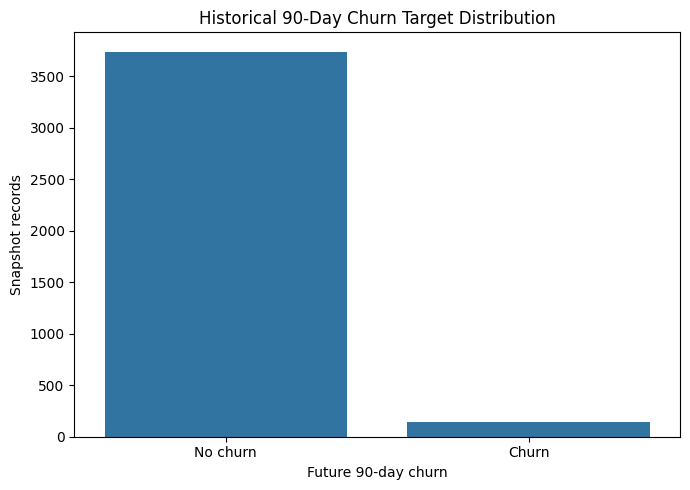

In [22]:
# Cell 13 — Check the historical target distribution
display(
    snapshots["churn_90d"]
    .value_counts()
    .rename({0: "No churn", 1: "Churn"})
    .to_frame("records")
)

plt.figure(figsize=(7, 5))
sns.countplot(data=snapshots, x="churn_90d")
plt.title("Historical 90-Day Churn Target Distribution")
plt.xlabel("Future 90-day churn")
plt.ylabel("Snapshot records")
plt.xticks([0, 1], ["No churn", "Churn"])
plt.tight_layout()
plt.show()


In [23]:
# Cell 14 — Define features and train/test data
feature_cols = [
    "invoice_count_90d",
    "revenue_90d",
    "amount_due_90d",
    "amount_paid_90d",
    "payment_rate_90d",
    "open_invoices_90d",
    "avg_mrr_90d",
    "avg_seats_90d",
    "days_since_last",
    "invoice_count_30d",
    "revenue_30d",
    "current_seats",
    "current_mrr",
    "region",
    "plan_name"
]

numeric_cols = [
    c for c in feature_cols
    if c not in ["region", "plan_name"]
]

categorical_cols = ["region", "plan_name"]

train = snapshots[snapshots["snapshot"] < "2025-01-01"].copy()
test = snapshots[snapshots["snapshot"] >= "2025-01-01"].copy()

X_train = train[feature_cols]
y_train = train["churn_90d"]

X_test = test[feature_cols]
y_test = test["churn_90d"]

print("Training rows:", f"{len(train):,}")
print("Testing rows:", f"{len(test):,}")
print(f"Training churn rate: {y_train.mean():.2%}")
print(f"Testing churn rate: {y_test.mean():.2%}")


Training rows: 1,855
Testing rows: 2,028
Training churn rate: 2.80%
Testing churn rate: 4.44%


In [24]:
# Cell 15 — Preprocessing pipeline
preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            Pipeline([
                ("imputer", SimpleImputer(strategy="median")),
                ("scaler", StandardScaler())
            ]),
            numeric_cols
        ),
        (
            "cat",
            Pipeline([
                ("imputer", SimpleImputer(strategy="most_frequent")),
                ("onehot", OneHotEncoder(handle_unknown="ignore"))
            ]),
            categorical_cols
        )
    ]
)

print("Preprocessing pipeline created.")


Preprocessing pipeline created.


In [25]:
# Cell 16 — Train two classification models
logistic_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(
        max_iter=2000,
        class_weight="balanced",
        random_state=42
    ))
])

random_forest_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestClassifier(
        n_estimators=300,
        min_samples_leaf=4,
        class_weight="balanced_subsample",
        random_state=42,
        n_jobs=-1
    ))
])

logistic_model.fit(X_train, y_train)
random_forest_model.fit(X_train, y_train)

print("Logistic Regression trained.")
print("Random Forest trained.")


Logistic Regression trained.
Random Forest trained.


In [26]:
# Cell 17 — Evaluate models
def evaluate_model(name, model, X, y, threshold=0.50):
    probability = model.predict_proba(X)[:, 1]
    prediction = (probability >= threshold).astype(int)

    return {
        "Model": name,
        "ROC-AUC": roc_auc_score(y, probability),
        "PR-AUC": average_precision_score(y, probability),
        "Precision": precision_score(y, prediction, zero_division=0),
        "Recall": recall_score(y, prediction, zero_division=0),
        "F1": f1_score(y, prediction, zero_division=0)
    }, probability, prediction


lr_result, lr_probability, lr_prediction = evaluate_model(
    "Logistic Regression",
    logistic_model,
    X_test,
    y_test
)

rf_result, rf_probability, rf_prediction = evaluate_model(
    "Random Forest",
    random_forest_model,
    X_test,
    y_test
)

model_results = pd.DataFrame([lr_result, rf_result])

display(model_results)


,Model,ROC-AUC,PR-AUC,Precision,Recall,F1
0,Logistic Regression,0.86,0.52,0.50,0.68,0.57
1,Random Forest,0.83,0.70,0.97,0.67,0.79


Random Forest classification report:
              precision    recall  f1-score   support

    No churn       0.98      1.00      0.99      1938
       Churn       0.97      0.67      0.79        90

    accuracy                           0.98      2028
   macro avg       0.98      0.83      0.89      2028
weighted avg       0.98      0.98      0.98      2028



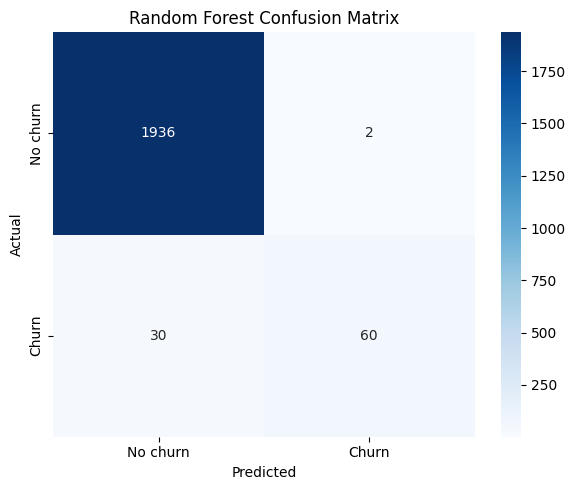

In [27]:
# Cell 18 — Random Forest evaluation details
print("Random Forest classification report:")
print(
    classification_report(
        y_test,
        rf_prediction,
        target_names=["No churn", "Churn"],
        zero_division=0
    )
)

cm = confusion_matrix(y_test, rf_prediction)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No churn", "Churn"],
    yticklabels=["No churn", "Churn"]
)
plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()


In [28]:
# Cell 19 — Build current client features
def build_current_features(data, score_date):
    past = data[data["invoice_date"] <= score_date].copy()

    last_invoice = past.groupby("account_id")["invoice_date"].max()

    # Score only currently active clients.
    eligible = last_invoice[
        (score_date - last_invoice).dt.days <= 90
    ].index

    w90 = past[
        past["invoice_date"] > score_date - pd.Timedelta(days=90)
    ]
    g90 = w90.groupby("account_id")

    feat = pd.DataFrame(index=eligible)

    feat["invoice_count_90d"] = (
        g90.size().reindex(eligible).fillna(0)
    )

    feat["revenue_90d"] = (
        g90["amount_paid"].sum().reindex(eligible).fillna(0)
    )

    feat["amount_due_90d"] = (
        g90["amount_due"].sum().reindex(eligible).fillna(0)
    )

    feat["amount_paid_90d"] = (
        g90["amount_paid"].sum().reindex(eligible).fillna(0)
    )

    feat["payment_rate_90d"] = np.divide(
        feat["amount_paid_90d"],
        feat["amount_due_90d"],
        out=np.zeros(len(feat), dtype=float),
        where=feat["amount_due_90d"].to_numpy() != 0
    )

    feat["open_invoices_90d"] = (
        g90["invoice_status"]
        .apply(lambda s: (s == "open").sum())
        .reindex(eligible)
        .fillna(0)
    )

    feat["avg_mrr_90d"] = (
        g90["mrr"].mean().reindex(eligible).fillna(0)
    )

    feat["avg_seats_90d"] = (
        g90["seats"].mean().reindex(eligible).fillna(0)
    )

    feat["days_since_last"] = (
        score_date - last_invoice.reindex(eligible)
    ).dt.days

    w30 = past[
        past["invoice_date"] > score_date - pd.Timedelta(days=30)
    ]
    g30 = w30.groupby("account_id")

    feat["invoice_count_30d"] = (
        g30.size().reindex(eligible).fillna(0)
    )

    feat["revenue_30d"] = (
        g30["amount_paid"].sum().reindex(eligible).fillna(0)
    )

    latest_rows = (
        past[past["account_id"].isin(eligible)]
        .sort_values("invoice_date")
        .groupby("account_id")
        .tail(1)
        .set_index("account_id")
    )

    feat["current_seats"] = latest_rows["seats"].reindex(eligible)
    feat["current_mrr"] = latest_rows["mrr"].reindex(eligible)
    feat["region"] = latest_rows["region"].reindex(eligible).fillna("Unknown")
    feat["plan_name"] = latest_rows["plan_name"].reindex(eligible)

    feat["account_id"] = feat.index

    return feat.reset_index(drop=True)


current_features = build_current_features(ent, latest_date)

current_features["churn_probability"] = (
    random_forest_model
    .predict_proba(current_features[feature_cols])[:, 1]
)

current_features["risk"] = pd.cut(
    current_features["churn_probability"],
    bins=[-0.001, 0.30, 0.50, 1.0],
    labels=["Low", "Medium", "High"]
)

risk_table = current_features[
    [
        "account_id",
        "churn_probability",
        "risk",
        "days_since_last",
        "current_mrr",
        "current_seats",
        "region",
        "plan_name"
    ]
].sort_values("churn_probability", ascending=False)

print("Currently active enterprise clients scored:", len(risk_table))

display(risk_table.head(20))


Currently active enterprise clients scored: 250


,account_id,churn_probability,risk,days_since_last,current_mrr,current_seats,region,plan_name
161,A003128,1.00,High,40,"2,499.00",337,EMEA,Enterprise
16,A000394,0.98,High,39,"2,499.00",241,EMEA,Enterprise
21,A000504,0.64,High,83,829.00,105,APAC,Scale
172,A003365,0.57,High,24,"2,499.00",310,EMEA,Enterprise
123,A002426,0.56,High,24,"2,499.00",329,APAC,Enterprise
145,A002923,0.52,High,16,"2,499.00",290,EMEA,Enterprise
98,A002031,0.49,Medium,19,"2,499.00",355,LATAM,Enterprise
223,A004407,0.48,Medium,18,"2,499.00",377,APAC,Enterprise
132,A002619,0.47,Medium,26,"2,499.00",290,APAC,Enterprise
135,A002679,0.47,Medium,16,"2,499.00",286,LATAM,Enterprise


,client_count
risk,
Low,154
Medium,90
High,6


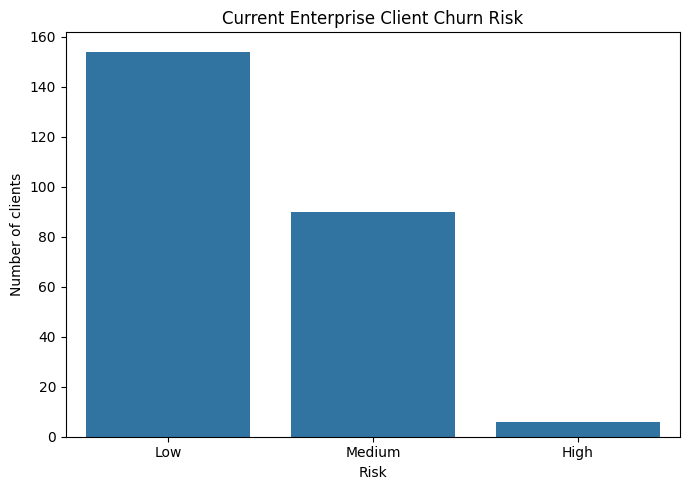

In [29]:
# Cell 20 — Risk summary
risk_summary = (
    risk_table["risk"]
    .value_counts()
    .reindex(["Low", "Medium", "High"])
    .fillna(0)
    .astype(int)
    .to_frame("client_count")
)

display(risk_summary)

plt.figure(figsize=(7, 5))
sns.countplot(
    data=risk_table,
    x="risk",
    order=["Low", "Medium", "High"]
)
plt.title("Current Enterprise Client Churn Risk")
plt.xlabel("Risk")
plt.ylabel("Number of clients")
plt.tight_layout()
plt.show()


,feature,importance
8,days_since_last,0.28
10,revenue_30d,0.13
9,invoice_count_30d,0.13
7,avg_seats_90d,0.11
11,current_seats,0.11
0,invoice_count_90d,0.05
1,revenue_90d,0.03
2,amount_due_90d,0.02
3,amount_paid_90d,0.02
12,current_mrr,0.02


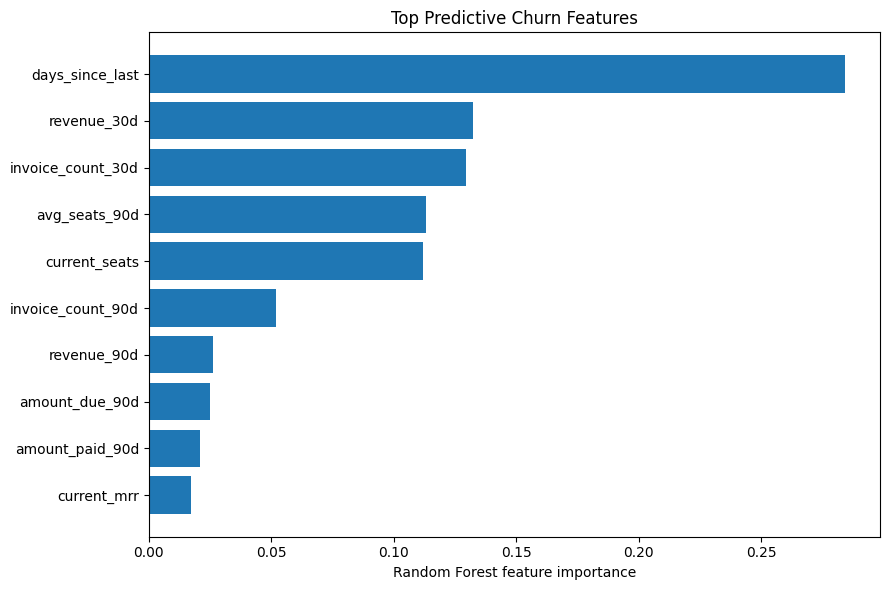

In [30]:
# Cell 21 — Feature importance
fitted_rf = random_forest_model.named_steps["model"]
fitted_preprocessor = random_forest_model.named_steps["preprocessor"]

onehot = (
    fitted_preprocessor
    .named_transformers_["cat"]
    .named_steps["onehot"]
)

feature_names = numeric_cols + list(
    onehot.get_feature_names_out(categorical_cols)
)

importance = (
    pd.DataFrame({
        "feature": feature_names,
        "importance": fitted_rf.feature_importances_
    })
    .sort_values("importance", ascending=False)
)

display(importance.head(15))

top10 = importance.head(10).sort_values("importance")

plt.figure(figsize=(9, 6))
plt.barh(top10["feature"], top10["importance"])
plt.title("Top Predictive Churn Features")
plt.xlabel("Random Forest feature importance")
plt.tight_layout()
plt.show()


In [31]:
# Cell 22 — Monthly enterprise billed revenue
monthly_revenue = (
    ent.set_index("invoice_date")["amount_due"]
    .resample("ME")
    .sum()
)

print("Monthly revenue observations:", len(monthly_revenue))
display(monthly_revenue.tail(12).to_frame("enterprise_billed_revenue"))


Monthly revenue observations: 36


,enterprise_billed_revenue
invoice_date,
2025-01-31,"361,140.00"
2025-02-28,"368,793.00"
2025-03-31,"377,718.00"
2025-04-30,"393,607.00"
2025-05-31,"406,895.00"
2025-06-30,"424,520.00"
2025-07-31,"434,438.00"
2025-08-31,"454,292.00"
2025-09-30,"470,884.00"


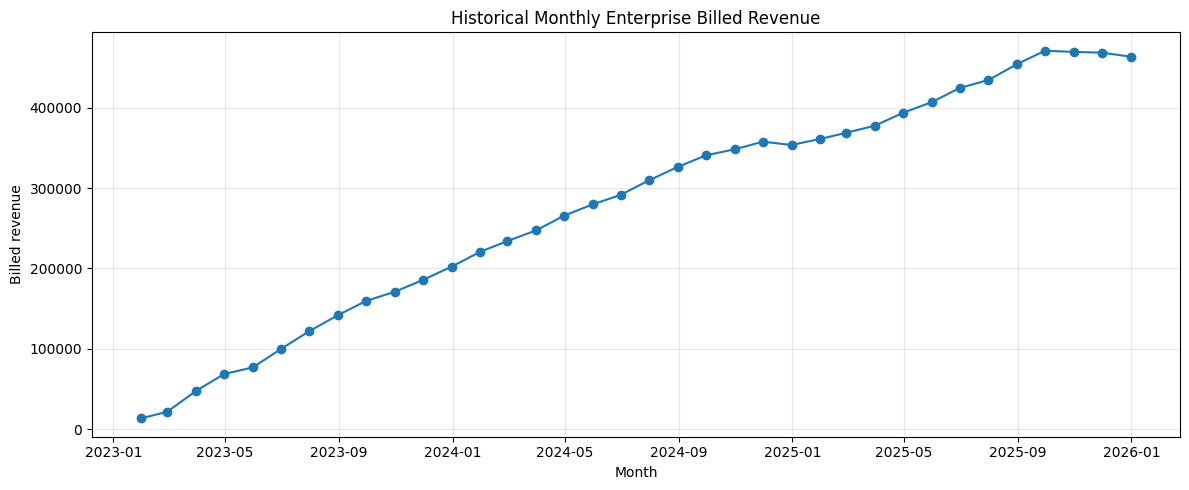

In [32]:
# Cell 23 — Plot historical revenue
plt.figure(figsize=(12, 5))
plt.plot(
    monthly_revenue.index,
    monthly_revenue.values,
    marker="o"
)
plt.title("Historical Monthly Enterprise Billed Revenue")
plt.xlabel("Month")
plt.ylabel("Billed revenue")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


,Metric,Value
0,MAE,"18,365.00"
1,RMSE,"22,474.90"
2,MAPE,3.97


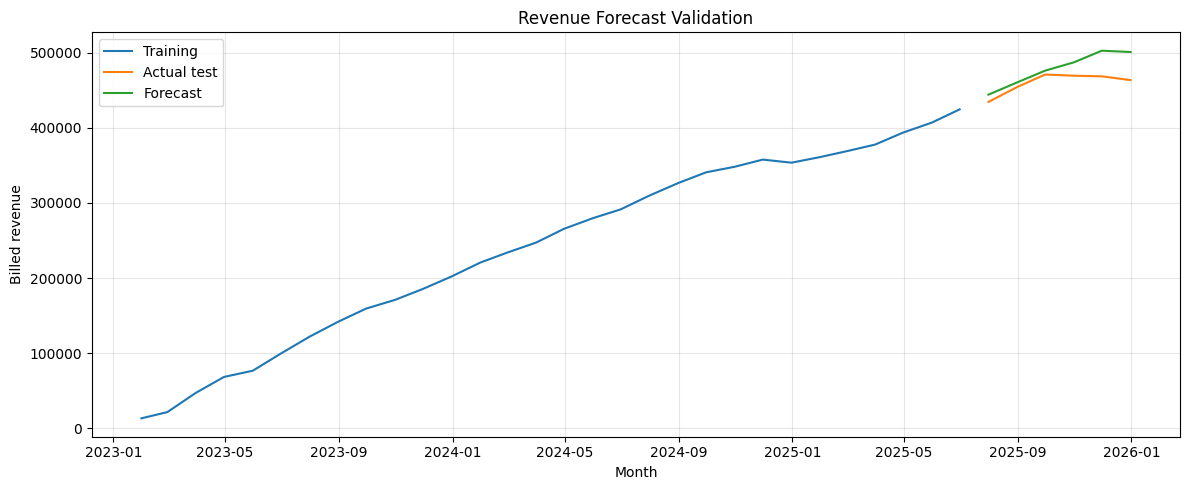

In [33]:
# Cell 24 — Validate the forecasting model
forecast_train = monthly_revenue.iloc[:-6]
forecast_test = monthly_revenue.iloc[-6:]

hw_validation_model = ExponentialSmoothing(
    forecast_train,
    trend="add",
    seasonal="add",
    seasonal_periods=12,
    initialization_method="estimated"
).fit()

validation_prediction = hw_validation_model.forecast(6)

mae = np.mean(
    np.abs(forecast_test - validation_prediction)
)

rmse = np.sqrt(
    np.mean((forecast_test - validation_prediction) ** 2)
)

mape = np.mean(
    np.abs(
        (forecast_test - validation_prediction) /
        forecast_test.replace(0, np.nan)
    )
) * 100

forecast_metrics = pd.DataFrame({
    "Metric": ["MAE", "RMSE", "MAPE"],
    "Value": [mae, rmse, mape]
})

display(forecast_metrics)

plt.figure(figsize=(12, 5))
plt.plot(forecast_train.index, forecast_train.values, label="Training")
plt.plot(forecast_test.index, forecast_test.values, label="Actual test")
plt.plot(validation_prediction.index, validation_prediction.values, label="Forecast")
plt.title("Revenue Forecast Validation")
plt.xlabel("Month")
plt.ylabel("Billed revenue")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


In [34]:
# Cell 25 — Final 12-month revenue forecast
final_forecast_model = ExponentialSmoothing(
    monthly_revenue,
    trend="add",
    seasonal="add",
    seasonal_periods=12,
    initialization_method="estimated"
).fit()

future_revenue = final_forecast_model.forecast(12)

revenue_forecast = future_revenue.reset_index()
revenue_forecast.columns = ["month", "forecast_billed_revenue"]

display(revenue_forecast)

print(
    "Forecasted total revenue for next 12 months:",
    f"{future_revenue.sum():,.2f}"
)


,month,forecast_billed_revenue
0,2026-01-31,"462,922.02"
1,2026-02-28,"472,971.77"
2,2026-03-31,"491,856.06"
3,2026-04-30,"504,320.38"
4,2026-05-31,"510,610.63"
5,2026-06-30,"521,059.48"
6,2026-07-31,"532,702.12"
7,2026-08-31,"545,930.19"
8,2026-09-30,"556,707.61"
9,2026-10-31,"559,094.05"


Forecasted total revenue for next 12 months: 6,277,137.74


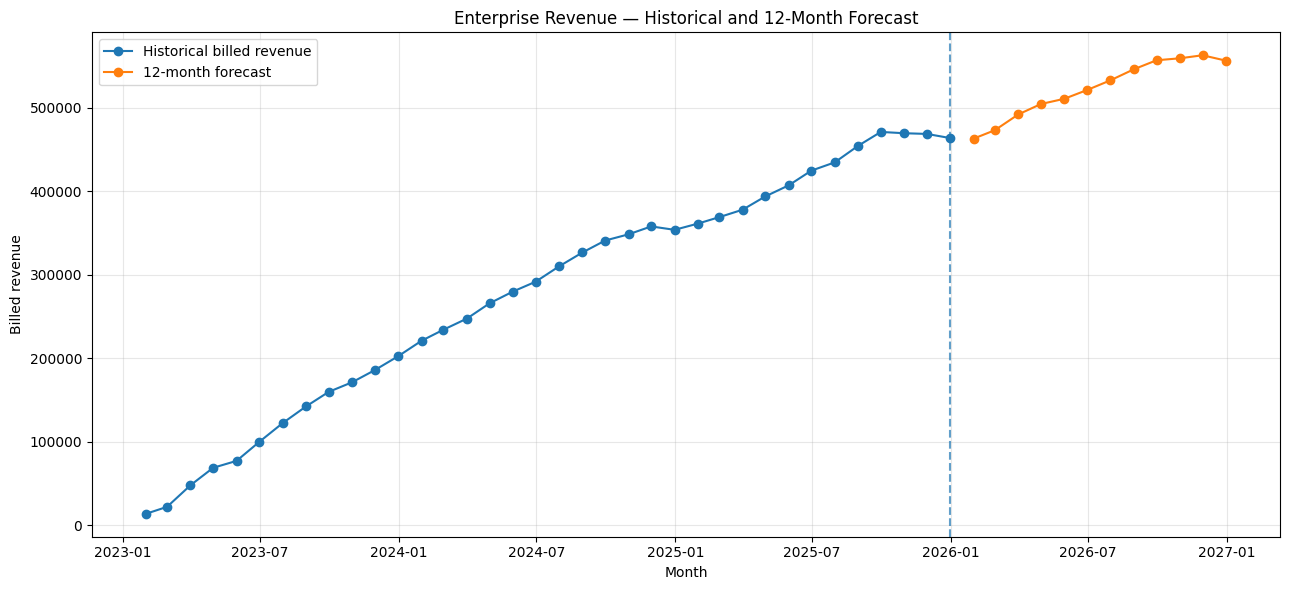

In [35]:
# Cell 26 — Historical + forecast chart
plt.figure(figsize=(13, 6))

plt.plot(
    monthly_revenue.index,
    monthly_revenue.values,
    label="Historical billed revenue",
    marker="o"
)

plt.plot(
    future_revenue.index,
    future_revenue.values,
    label="12-month forecast",
    marker="o"
)

plt.axvline(
    monthly_revenue.index[-1],
    linestyle="--",
    alpha=0.7
)

plt.title("Enterprise Revenue — Historical and 12-Month Forecast")
plt.xlabel("Month")
plt.ylabel("Billed revenue")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


In [36]:
# Cell 27 — Calculate churn reduction targets
current_rate = current_churn_rate

relative_target_rate = current_rate * 0.95
percentage_point_target_rate = max(current_rate - 0.05, 0)

target_summary = pd.DataFrame({
    "Scenario": [
        "Current",
        "5% relative reduction",
        "5 percentage-point reduction"
    ],
    "Churn_rate": [
        current_rate,
        relative_target_rate,
        percentage_point_target_rate
    ]
})

target_summary["Churn_rate"] = (
    target_summary["Churn_rate"] * 100
).round(2)

display(target_summary)

current_churned_clients = current_account_status["churned_90d"].sum()

print(f"Current churned clients: {current_churned_clients}")
print(
    "Approx. churned clients at 5% relative reduction:",
    round(current_churned_clients * 0.95)
)
print(
    "Approx. churned clients at 5 percentage-point reduction:",
    round(len(current_account_status) * percentage_point_target_rate)
)


,Scenario,Churn_rate
0,Current,18.03
1,5% relative reduction,17.13
2,5 percentage-point reduction,13.03


Current churned clients: 55
Approx. churned clients at 5% relative reduction: 52
Approx. churned clients at 5 percentage-point reduction: 40


In [37]:
# Cell 28 — Create a practical retention priority table
retention_priority = risk_table.copy()

retention_priority["estimated_monthly_revenue_at_risk"] = (
    retention_priority["current_mrr"]
)

retention_priority["priority"] = np.where(
    (retention_priority["risk"].eq("High")) &
    (retention_priority["current_mrr"] >= retention_priority["current_mrr"].median()),
    "Immediate",
    np.where(
        retention_priority["risk"].eq("High"),
        "High",
        np.where(
            retention_priority["risk"].eq("Medium"),
            "Monitor",
            "Routine"
        )
    )
)

display(
    retention_priority[
        [
            "account_id",
            "churn_probability",
            "risk",
            "priority",
            "days_since_last",
            "current_mrr",
            "region",
            "plan_name"
        ]
    ].head(20)
)


,account_id,churn_probability,risk,priority,days_since_last,current_mrr,region,plan_name
161,A003128,1.00,High,Immediate,40,"2,499.00",EMEA,Enterprise
16,A000394,0.98,High,Immediate,39,"2,499.00",EMEA,Enterprise
21,A000504,0.64,High,High,83,829.00,APAC,Scale
172,A003365,0.57,High,Immediate,24,"2,499.00",EMEA,Enterprise
123,A002426,0.56,High,Immediate,24,"2,499.00",APAC,Enterprise
145,A002923,0.52,High,Immediate,16,"2,499.00",EMEA,Enterprise
98,A002031,0.49,Medium,Monitor,19,"2,499.00",LATAM,Enterprise
223,A004407,0.48,Medium,Monitor,18,"2,499.00",APAC,Enterprise
132,A002619,0.47,Medium,Monitor,26,"2,499.00",APAC,Enterprise
135,A002679,0.47,Medium,Monitor,16,"2,499.00",LATAM,Enterprise


In [38]:
# Cell 29 — Export results
risk_table.to_csv("enterprise_churn_risk.csv", index=False)
importance.to_csv("churn_feature_importance.csv", index=False)
revenue_forecast.to_csv("enterprise_revenue_forecast_12_months.csv", index=False)
model_results.to_csv("model_comparison.csv", index=False)
forecast_metrics.to_csv("forecast_validation_metrics.csv", index=False)
target_summary.to_csv("churn_target_summary.csv", index=False)

print("Export completed successfully.")
print("Files created:")
print("1. enterprise_churn_risk.csv")
print("2. churn_feature_importance.csv")
print("3. enterprise_revenue_forecast_12_months.csv")
print("4. model_comparison.csv")
print("5. forecast_validation_metrics.csv")
print("6. churn_target_summary.csv")


Export completed successfully.
Files created:
1. enterprise_churn_risk.csv
2. churn_feature_importance.csv
3. enterprise_revenue_forecast_12_months.csv
4. model_comparison.csv
5. forecast_validation_metrics.csv
6. churn_target_summary.csv
